In [1]:
import torch
import time
import warnings
import os
from tqdm import tqdm
from torch.utils.tensorboard import SummaryWriter

from device import setup_device
from datasets.utk_dataset import UTKFaceDataset
from datasets.loading import get_full_loader
from model.encoder import Encoder
from model.loading import load_model
from loss import *
from train_encoder import *
from visualization import *
from utils.extraction import extract_embeddings
from analysis.monitor import (
    CompositeMonitor,
    LoggingMonitor,
    OptimumMonitor,
    EarlyStoppingMonitor,
    SaveModelMonitor,
    TensorboardMonitor,
)

In [2]:
warnings.filterwarnings("ignore", message=".*force_all_finite.*")

from numba.core.errors import NumbaWarning
warnings.filterwarnings("ignore", category=NumbaWarning)

warnings.filterwarnings("ignore", message=".*verbose parameter is deprecated.*")

In [3]:
verbose=True

In [4]:
device, data_parallel = setup_device(use_gpu_1_only=False, verbose=verbose)

[15:28:40] [INFO] ✅ CUDA is available: 2 GPU(s) visible


In [5]:
backbone_model = 'resnet50'
pretrained = True
model = Encoder(backbone_name=backbone_model, pretrained=pretrained)
model = data_parallel(model).to(device)

[15:28:40] [INFO] 🚀 Wrapping model in DataParallel over 2 GPUs


In [6]:
test_dir = './outputs/current/initial_test'
best_model_file = os.path.join(test_dir, 'best_model.pth')
key_metric = 'kendall'
mode = 'max'
analysis_dir = os.path.join(test_dir, 'analysis')

In [7]:
writer = SummaryWriter(log_dir=test_dir)
monitor = CompositeMonitor([
    LoggingMonitor(key_metric=key_metric, mode=mode, verbose=True),
    OptimumMonitor(key_metric=key_metric, mode=mode, save_path=best_model_file, verbose=verbose),
    EarlyStoppingMonitor(key_metric=key_metric, patience=10, delta=1e-4, mode=mode, verbose=verbose),
    SaveModelMonitor(save_dir=analysis_dir),
    TensorboardMonitor(writer)
])

In [8]:
config = {
    'device': device,
    'data_folder': './data/utkface/UTKFace',
    'model': model
}

train_config = {
    'batch_size': 256,
    'num_epochs': 2,
    'learning_rate': 1e-3,
    'temperature': 0.5,
    'augmentations': 'crop,flip,color,grayscale',
    'train_size': 0.8,
    'metrics': [
        "val_loss",
        "embedding_norm",
        "embedding_variance",
        "knn_accuracy",
        "spearman",
        "kendall",
        "grad_norm",
        "lr"
    ],
    'monitor': monitor
}

In [9]:
start_time = time.time()
train_encoder({**config, **train_config}, verbose=verbose)
end_time = time.time()
print_verbose(f"Training completed in: {end_time - start_time:.2f} seconds", verbose)

[15:28:40] [INFO] Configuration check passed: 10 keys found.
[15:28:40] [INFO] Configuration check passed: 9 keys found.
[15:28:40] [INFO] Training on device: cuda


Extracting Embeddings: 100%|██████████████████████████████| 19/19 [ 6.53batch/s]


[15:29:43] [INFO] [Epoch 0] kendall: 0.4331 (max)
[15:29:44] [INFO] ✅ New best kendall: 0.4331 (max)


Extracting Embeddings: 100%|██████████████████████████████| 19/19 [ 6.35batch/s]


[15:30:47] [INFO] [Epoch 1] kendall: 0.4420 (max)
[15:30:47] [INFO] ✅ New best kendall: 0.4420 (max)
[15:30:47] [INFO] Training complete!
[15:30:47] [INFO] Training completed in: 127.14 seconds


In [10]:
model = load_model(model, best_model_file, verbose=verbose)
full_loader = get_full_loader('./data/utkface/UTKFace')

# Disable the projection layer
if hasattr(model, 'projector'):
    model.projector = nn.Identity()
        
embeddings, labels = extract_embeddings(model, full_loader, device=device, verbose=verbose)
print_verbose(f"Shape of embeddings: {tuple(embeddings.shape)}", verbose)
print_verbose(f"Memory usage of embeddings: {embeddings.nbytes / (1024 ** 2):.2f} MB", verbose) 

[15:30:47] [INFO] Loaded model from ./outputs/current/initial_test/best_model.pth, epoch 1, best loss: 4.9834


Extracting Embeddings: 100%|████████████████████████████| 371/371 [19.43batch/s]

[15:31:07] [INFO] Shape of embeddings: (23708, 128)
[15:31:07] [INFO] Memory usage of embeddings: 11.58 MB


In [11]:
checkpoint_dir = os.path.join(test_dir, 'analysis')
checkpoint_files = sorted(
    [f for f in os.listdir(checkpoint_dir) if f.startswith("epoch_") and f.endswith(".pt")]
)

embeddings_list = []
labels_list = []

full_loader = get_full_loader('./data/utkface/UTKFace')

for ckpt_file in checkpoint_files:
    model_path = os.path.join(checkpoint_dir, ckpt_file)
    
    # Load model from checkpoint
    model = load_model(model, model_path, verbose=verbose)
    model.to(device)
    model.eval()

    # Disable the projection layer if present
    if hasattr(model, 'projector'):
        model.projector = nn.Identity()

    # Extract embeddings and labels        
    embeddings, labels = extract_embeddings(model, full_loader, device=device, verbose=verbose)

    # Append
    embeddings_list.append(embeddings)
    labels_list.append(labels)

[15:31:07] [INFO] Loaded model from ./outputs/current/initial_test/analysis/epoch_000.pt, epoch 0, best loss: 5.0799


Extracting Embeddings: 100%|████████████████████████████| 371/371 [19.61batch/s]


[15:31:26] [INFO] Loaded model from ./outputs/current/initial_test/analysis/epoch_001.pt, epoch 1, best loss: 4.9781


Extracting Embeddings: 100%|████████████████████████████| 371/371 [20.02batch/s]


[15:31:44] [INFO] [visualize] Running: umap
[15:32:06] [INFO] [plot_umap] embeddings: (23708, 128), labels: (23708,)


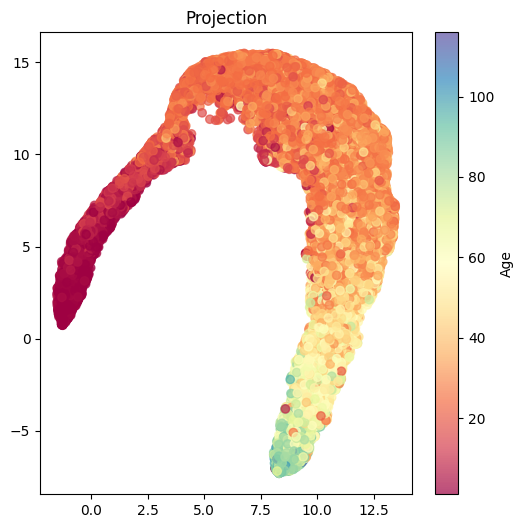

[15:32:06] [INFO] [visualize] Running: similarity_matrix
[15:32:07] [INFO] [plot_similarity_matrix] embeddings: torch.Size([1500, 128]), labels: torch.Size([1500])


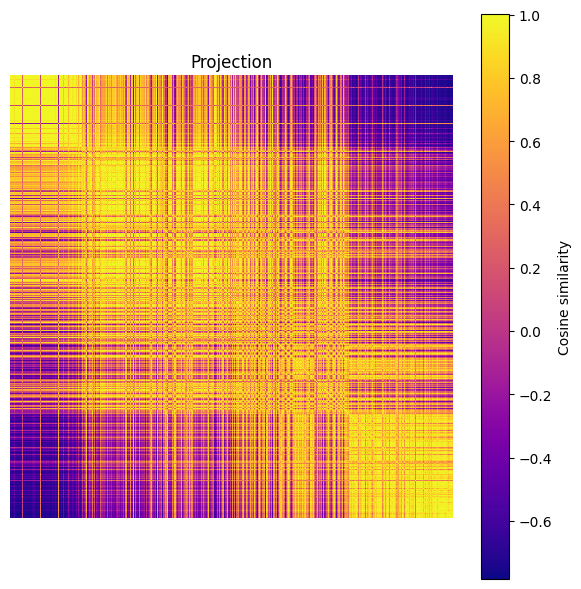

[15:32:07] [INFO] [visualize] Running: umap_all
[15:32:15] [INFO] [plot_umap_all_epochs_grid] Epoch 0: (23708, 128), (23708,)
[15:32:22] [INFO] [plot_umap_all_epochs_grid] Epoch 1: (23708, 128), (23708,)


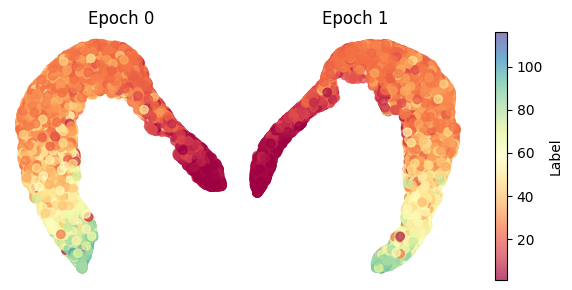

[15:32:23] [INFO] Visualization computed in: 38.71 seconds


In [12]:
selected = ['umap', 'similarity_matrix', 'umap_all']

args = {
    'embeddings': embeddings,
    'labels': labels,
    'figsize': (6, 6),
    'figssize': (3, 3),
    'n': 1500,
    'title': 'Projection',
    'embeddings_list': embeddings_list,
    'labels_list': labels_list
}

start_time = time.time()
visualize(selected, args, verbose=verbose)
end_time = time.time()

print_verbose(f"Visualization computed in: {end_time - start_time:.2f} seconds", verbose)